# T2.6 — Training the CNN + BiLSTM + Transformer ensemble on IoTID20

**Build-Instructions task:** T2.6 · **This is the Review 2 deliverable** (`PRD.md §8`, 7 September)
**Spec:** `TRD.md §3`, `docs/architecture_decision.md`

## What this notebook builds

The committed core of Contribution 2: three fully-specified branches over genuine flow
*sequences*, fused by confidence-weighted voting, trained on the leakage-free pipeline from T1.2
and compared honestly against that pipeline's Random Forest baseline.

| Branch | Exact specification (frozen in `docs/architecture_decision.md`) |
|---|---|
| CNN | 3 Conv1D layers, 64/128/64 filters, kernel 3, ReLU, dropout 0.3, GlobalMaxPooling1D |
| BiLSTM | **2 layers, 64 units per direction** (128-d state), dropout 0.3 |
| Transformer | 2 encoder layers, 4 heads, key_dim 16, embed dim 64, FFN 128, dropout 0.1 |
| Fusion | `w_b = alpha_b · c_b^gamma / Σ`, gamma = 1.0 — not an average, not a majority vote |

The BiLSTM row is the point: the base paper states **neither** its LSTM layer count **nor** its
unit count (Objection #2, `PRD.md §2.1.2`). Ours are stated here, in the module docstring, in the
decision document, and in the report this notebook writes.

## Positive-class convention

**`Attack` (label 1) is the positive class** — `TRD.md §2.3`, the opposite of the base paper's
choice. Every metric below is hand-verified from the raw confusion matrix under this convention.

In [1]:
import json
import logging
import sys
import time
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s", force=True)

from src.config import RANDOM_STATE
from src.evaluation.leakage_check import synthetic_contamination
from src.evaluation.metrics import (
    POSITIVE_CLASS_STATEMENT,
    compute_metrics,
    hand_verify_metrics,
    results_table,
)
from src.models import bilstm_branch, cnn_branch, transformer_branch
from src.models.fusion import (
    confidence_weighted_fusion,
    describe_formula,
    majority_vote_fusion,
    simple_average_fusion,
)
from src.models.train_utils import (
    compute_class_weights,
    describe_training_configuration,
    scale_sequences,
    set_global_seeds,
    train_branch,
)
from src.preprocessing.clean import clean_iotid20, load_iotid20
from src.preprocessing.feature_select import IOTID20_N_FEATURES, RandomForestFeatureSelector
from src.preprocessing.sequence_builder import (
    SEQUENCE_LENGTH,
    TRAIN_STRIDE,
    assign_sessions,
    build_sequences,
    split_sessions,
)

set_global_seeds(RANDOM_STATE)
print(POSITIVE_CLASS_STATEMENT)
print("\n" + describe_training_configuration())
print("\n" + bilstm_branch.describe_architecture())
print("\n" + transformer_branch.describe_architecture())

INFO | Global seeds set to 42 with op determinism enabled


POSITIVE CLASS = Attack (label 1); negative class = Normal (label 0). This is TRD.md §2.3's convention and is the OPPOSITE of the base paper's, which uses Normal as positive (PRD.md §2.1.3).

Adam(lr=0.001), loss=categorical_crossentropy, batch_size=256, max_epochs=50, EarlyStopping(monitor='val_positive_f1', mode='max', patience=5, restore_best_weights=True), seed=42. Class imbalance handled by inverse-frequency class weights, NOT SMOTE -- see this module's docstring for why SMOTE is inappropriate for flow sequences.

BiLSTM branch: 2 Bidirectional LSTM layers, 64 units per direction (128-d concatenated state), merge_mode='concat', dropout 0.3, recurrent_dropout 0.0, projected to a 64-d embedding, 2-unit softmax head. The base paper states neither its LSTM layer count nor its unit count (Objection #2, PRD.md §2.1.2).

Transformer branch: 2 encoder layers, 4 attention heads, key_dim 16, embedding dimension 64, feed-forward dimension 128, dropout 0.1, fixed sinusoidal positional encodin

## Step 1 — Load, clean, and deduplicate

Cleaning matches the **pipeline C** baseline from T1.2 Step 11: the honest split order *and*
deduplication. T1.2 showed that fixing the SMOTE ordering alone leaves 58.2% duplicate rows in
play, a larger leakage vector; both fixes are applied from here on.

In [2]:
raw = load_iotid20()
X, y, meta = clean_iotid20(raw, drop_duplicates=True)
print(f"Cleaned + deduplicated: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Attack (positive, 1): {int((y == 1).sum()):,}   Normal (0): {int((y == 0).sum()):,}")

INFO | Loaded IoTID20: 625783 rows x 86 columns from /Users/rohithpranov/.cache/kagglehub/datasets/rohulaminlabid/iotid20-dataset/versions/2/IoT Network Intrusion Dataset.csv


INFO | Feature funnel: 83 raw -> 79 after removing 4 identifier columns


INFO | Replaced 736 infinite values with NaN


INFO | Dropped 368 rows containing NaN (625415 remain)


INFO | Dropped 10 zero-variance columns -> 69 features


INFO | Exact duplicate feature rows present: 363884 (drop_duplicates=True)


INFO | Dropped duplicates -> 261531 rows remain


INFO | Clean complete: X=(261531, 69), class balance -> Attack(1)=234002, Normal(0)=27529


Cleaned + deduplicated: 261,531 rows × 69 features
Attack (positive, 1): 234,002   Normal (0): 27,529


## Step 2 — Sessionise, then split by **session**

Sessions are per-destination-device, broken by a 1-second inactivity gap
(`docs/architecture_decision.md` §1.1). `Dst_IP` is the device being protected, and it is the only
candidate key whose median group size exceeds 1 — grouping by `Src_IP` or `Flow_ID` would leave
most windows padded from a single record, which is Objection #2 through the back door.

**The split is by session, never by window** (§1.4). Adjacent windows within a session share up to
9 of their 10 records, so splitting windows directly would put near-identical windows on both
sides — the very bug this project exists to expose, reintroduced by our own sequence builder.

The assignment is also **size-aware**: IoTID20 session sizes are extremely skewed, and assigning
sessions uniformly at random gives folds that are 98% / 39% / 96% Attack — not comparable to one
another. Bin-packing sessions largest-first into window quotas fixes that.

In [3]:
sessions = assign_sessions(meta)
print(f"{sessions.nunique():,} sessions over {meta['Dst_IP'].nunique():,} destination devices")

train_sessions, test_sessions, val_sessions = split_sessions(sessions, y)
row_fold = {
    "train": sessions.isin(train_sessions).to_numpy(),
    "test": sessions.isin(test_sessions).to_numpy(),
    "val": sessions.isin(val_sessions).to_numpy(),
}
for name, mask in row_fold.items():
    print(f"  {name:<5s} {int(mask.sum()):>7,} rows  ({mask.mean():.1%})")

assert not (set(train_sessions) & set(test_sessions)), "session leaked between train and test"
assert not (set(train_sessions) & set(val_sessions)), "session leaked between train and validation"
print("\nNo session appears in more than one fold.")

INFO | Assigned 4242 sessions over 471 devices (gap > 1.0s)


INFO | Session-level split: 1475 train / 1315 test / 1452 validation sessions


4,242 sessions over 471 destination devices
  train 209,025 rows  (79.9%)
  test   26,554 rows  (10.2%)
  val    25,952 rows  (9.9%)

No session appears in more than one fold.


## Step 3 — Feature selection on the **training fold only** (83 → 62)

Random Forest importance — *this project's own choice*, not the base paper's unreproducible PSO
(`docs/feature_selection_decision.md`). Fitted only on rows belonging to training sessions.

In [4]:
selector = RandomForestFeatureSelector(n_features=IOTID20_N_FEATURES, random_state=RANDOM_STATE)
selector.fit(X[row_fold["train"]], y[row_fold["train"]])
X_selected = selector.transform(X)
selector.ranking_.to_csv(REPO_ROOT / "reports" / "iotid20_feature_ranking_sequences.csv", index=False)
print(f"Selected {len(selector.selected_features_)} features on the training fold only")

INFO | Fitting RF selector on (209025, 69) to rank 69 features


INFO | Selected 62/69 features; top 5: ['Dst_Port', 'ACK_Flag_Cnt', 'Src_Port', 'Flow_Duration', 'Init_Bwd_Win_Byts']


Selected 62 features on the training fold only


## Step 4 — Build windows **within each fold**

Windows are constructed per fold rather than globally, so no window can straddle the split.
Window length **10**, training stride **5** (50% overlap). Each window is labelled by its **last**
record — causal, and never requiring a label from the future (§1.3).

In [5]:
folds: dict[str, object] = {}
for name, mask in row_fold.items():
    folds[name] = build_sequences(
        X_selected[mask].reset_index(drop=True),
        y[mask].reset_index(drop=True),
        meta[mask].reset_index(drop=True),
        sequence_length=SEQUENCE_LENGTH,
        stride=TRAIN_STRIDE,
        session_ids=sessions[mask].reset_index(drop=True),
    )
    print(f"\n{name.upper()}\n{folds[name].summary()}")

INFO | Built 41284 windows (stride=5); dropped 436 sessions shorter than 2 records (436 rows)


INFO | SequenceDataset: X=(41284, 10, 62) (batch, sequence_length, features)
  sequence_length          : 10  (> 1, TRD.md §9 gate)
  windows                  : 41,284
  distinct sessions        : 1,039
  Attack(1) / Normal(0)    : 37,006 / 4,278
  windows containing padding: 646 (1.6%)


INFO | Built 4894 windows (stride=5); dropped 399 sessions shorter than 2 records (399 rows)


INFO | SequenceDataset: X=(4894, 10, 62) (batch, sequence_length, features)
  sequence_length          : 10  (> 1, TRD.md §9 gate)
  windows                  : 4,894
  distinct sessions        : 916
  Attack(1) / Normal(0)    : 4,265 / 629
  windows containing padding: 605 (12.4%)


INFO | Built 4700 windows (stride=5); dropped 436 sessions shorter than 2 records (436 rows)


INFO | SequenceDataset: X=(4700, 10, 62) (batch, sequence_length, features)
  sequence_length          : 10  (> 1, TRD.md §9 gate)
  windows                  : 4,700
  distinct sessions        : 1,016
  Attack(1) / Normal(0)    : 4,274 / 426
  windows containing padding: 646 (13.7%)



TRAIN
SequenceDataset: X=(41284, 10, 62) (batch, sequence_length, features)
  sequence_length          : 10  (> 1, TRD.md §9 gate)
  windows                  : 41,284
  distinct sessions        : 1,039
  Attack(1) / Normal(0)    : 37,006 / 4,278
  windows containing padding: 646 (1.6%)

TEST
SequenceDataset: X=(4894, 10, 62) (batch, sequence_length, features)
  sequence_length          : 10  (> 1, TRD.md §9 gate)
  windows                  : 4,894
  distinct sessions        : 916
  Attack(1) / Normal(0)    : 4,265 / 629
  windows containing padding: 605 (12.4%)

VAL
SequenceDataset: X=(4700, 10, 62) (batch, sequence_length, features)
  sequence_length          : 10  (> 1, TRD.md §9 gate)
  windows                  : 4,700
  distinct sessions        : 1,016
  Attack(1) / Normal(0)    : 4,274 / 426
  windows containing padding: 646 (13.7%)


### The shape gate (`TRD.md §9`, "Sequences are real sequences")

In [6]:
train_ds, test_ds, val_ds = folds["train"], folds["test"], folds["val"]
print(f"Ensemble input shape: {train_ds.X.shape}  = (batch, sequence_length, features)")
assert train_ds.X.ndim == 3, "input must be 3-D, not (batch, features)"
assert train_ds.X.shape[1] == SEQUENCE_LENGTH > 1, "sequence_length must exceed 1"
print(f"sequence_length = {train_ds.X.shape[1]} > 1  ✓  (the base paper's input is a single record)")
print(f"features        = {train_ds.X.shape[2]}")

Ensemble input shape: (41284, 10, 62)  = (batch, sequence_length, features)
sequence_length = 10 > 1  ✓  (the base paper's input is a single record)
features        = 62


## Step 5 — Scale, with statistics from the **training fold only**

In [7]:
X_train, X_test, X_val = scale_sequences(train_ds.X, test_ds.X, val_ds.X)
y_train, y_test, y_val = train_ds.y, test_ds.y, val_ds.y

for name, y_fold in (("train", y_train), ("test", y_test), ("validation", y_val)):
    print(f"  {name:<11s} {len(y_fold):>7,} windows  Attack rate {float((y_fold == 1).mean()):.3f}")

INFO | Min-max scaling fitted on 41284 training windows


  train        41,284 windows  Attack rate 0.896
  test          4,894 windows  Attack rate 0.871
  validation    4,700 windows  Attack rate 0.909


### The test fold contains no synthetic data

`train_utils` handles imbalance with **class weights, not SMOTE** — SMOTE applied to a flattened
620-dimensional flow sequence would fabricate sessions blending two devices' traffic over time,
objects that cannot occur on a real network. See `src/models/train_utils.py`'s docstring. This
difference from the row-level baseline is stated in the report.

In [8]:
print(synthetic_contamination(y_test, None, "SEQUENCE pipeline", fold_name="test").summary())
class_weights = compute_class_weights(y_train)
print(f"\nClass weights (inverse frequency): {({k: round(v, 4) for k, v in class_weights.items()})}")

INFO | Synthetic-contamination check -- SEQUENCE pipeline
  test fold rows                 : 4,894
  of which SMOTE-generated              : 0 (0.00%)
  minority-class rows in the fold       : 629
  of those, SMOTE-generated             : 0.00%
  VERDICT: CLEAN: every row of the test fold is real observed traffic.


INFO | Class counts {0: 4278, 1: 37006} -> weights {0: 4.8252, 1: 0.5578}


Synthetic-contamination check -- SEQUENCE pipeline
  test fold rows                 : 4,894
  of which SMOTE-generated              : 0 (0.00%)
  minority-class rows in the fold       : 629
  of those, SMOTE-generated             : 0.00%
  VERDICT: CLEAN: every row of the test fold is real observed traffic.

Class weights (inverse frequency): {0: 4.8252, 1: 0.5578}


## Step 6 — Train the three branches

In [9]:
n_features = X_train.shape[2]
builders = {
    "cnn": cnn_branch.build_cnn_branch,
    "bilstm": bilstm_branch.build_bilstm_branch,
    "transformer": transformer_branch.build_transformer_branch,
}

models: dict[str, object] = {}
histories: dict[str, object] = {}
train_seconds: dict[str, float] = {}

for name, builder in builders.items():
    set_global_seeds(RANDOM_STATE)
    model = builder(SEQUENCE_LENGTH, n_features)
    print(f"\n=== {name} — {model.count_params():,} parameters ===")

    started = time.perf_counter()
    histories[name] = train_branch(
        model, X_train, y_train, X_val, y_val, class_weights=class_weights, verbose=0
    )
    train_seconds[name] = time.perf_counter() - started
    models[name] = model

    epochs_run = len(histories[name].history["loss"])
    best_f1 = max(histories[name].history["val_positive_f1"])
    print(f"    {epochs_run} epochs in {train_seconds[name]:.1f}s "
          f"(best validation positive-class F1 {best_f1:.4f})")

INFO | Global seeds set to 42 with op determinism enabled


INFO | Training cnn_branch on 41284 windows for up to 50 epochs



=== cnn — 62,466 parameters ===


E0000 00:00:1788807417.064721 44411308 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


INFO | Global seeds set to 42 with op determinism enabled


...

INFO | Training transformer_branch on 41284 windows for up to 50 epochs


    18 epochs in 94.3s (best validation positive-class F1 0.9846)

=== transformer — 71,106 parameters ===


E0000 00:00:1788807548.712836 44411308 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


E0000 00:00:1788807555.529261 44411308 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


    20 epochs in 77.5s (best validation positive-class F1 0.9746)


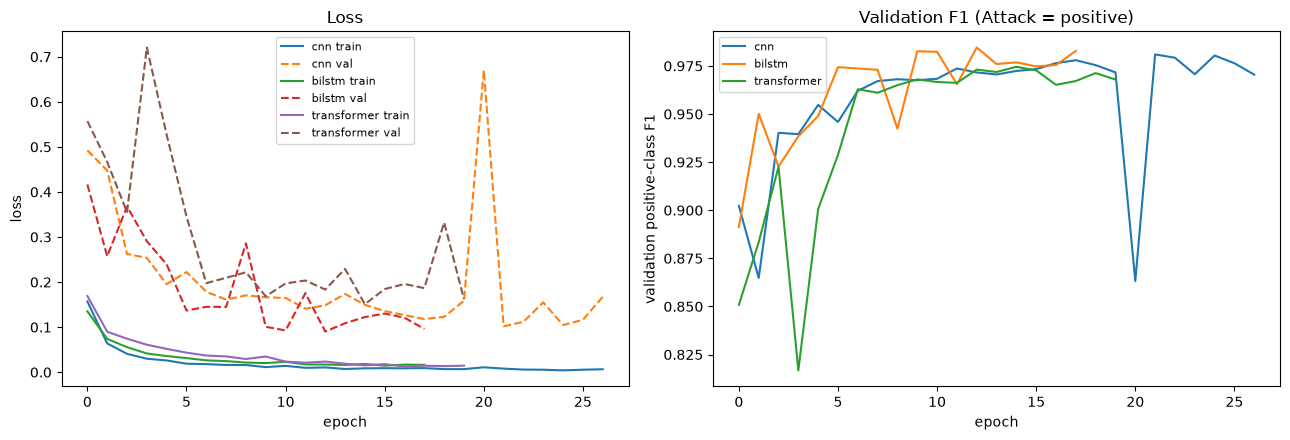

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, history in histories.items():
    axes[0].plot(history.history["loss"], label=f"{name} train")
    axes[0].plot(history.history["val_loss"], ls="--", label=f"{name} val")
    axes[1].plot(history.history["val_positive_f1"], label=name)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation positive-class F1")
axes[1].set_title("Validation F1 (Attack = positive)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Step 7 — Per-branch test-set performance

**Positive class = Attack (label 1).** Every metric is hand-verified against the confusion matrix.

In [11]:
branch_probabilities = {}
branch_results = []

for name, model in models.items():
    probabilities = model.predict(X_test, verbose=0)
    branch_probabilities[name] = probabilities
    result = hand_verify_metrics(
        compute_metrics(y_test, np.argmax(probabilities, axis=1), f"{name} branch alone"),
        verbose=False,
    )
    branch_results.append(result)
    print(result.report())
    print()

E0000 00:00:1788807626.463570 44411308 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


cnn branch alone
  POSITIVE CLASS = Attack (label 1); negative class = Normal (label 0). This is TRD.md §2.3's convention and is the OPPOSITE of the base paper's, which uses Normal as positive (PRD.md §2.1.3).
  Confusion matrix (Attack = positive):
      TP (Attack  -> Attack) = 4,149
      FN (Attack  -> Normal) = 116   <- missed attacks
      FP (Normal  -> Attack) = 261   <- false alarms
      TN (Normal  -> Normal) = 368
  Accuracy  = (TP+TN)/(TP+FP+TN+FN) = 0.922967
  Precision = TP/(TP+FP)            = 0.940816
  Recall    = TP/(TP+FN)            = 0.972802
  F1        = 2PR/(P+R)             = 0.956542
  hand-verified against the confusion matrix: True



bilstm branch alone
  POSITIVE CLASS = Attack (label 1); negative class = Normal (label 0). This is TRD.md §2.3's convention and is the OPPOSITE of the base paper's, which uses Normal as positive (PRD.md §2.1.3).
  Confusion matrix (Attack = positive):
      TP (Attack  -> Attack) = 4,229
      FN (Attack  -> Normal) = 36   <- missed attacks
      FP (Normal  -> Attack) = 321   <- false alarms
      TN (Normal  -> Normal) = 308
  Accuracy  = (TP+TN)/(TP+FP+TN+FN) = 0.927054
  Precision = TP/(TP+FP)            = 0.929451
  Recall    = TP/(TP+FN)            = 0.991559
  F1        = 2PR/(P+R)             = 0.959501
  hand-verified against the confusion matrix: True



transformer branch alone
  POSITIVE CLASS = Attack (label 1); negative class = Normal (label 0). This is TRD.md §2.3's convention and is the OPPOSITE of the base paper's, which uses Normal as positive (PRD.md §2.1.3).
  Confusion matrix (Attack = positive):
      TP (Attack  -> Attack) = 4,152
      FN (Attack  -> Normal) = 113   <- missed attacks
      FP (Normal  -> Attack) = 138   <- false alarms
      TN (Normal  -> Normal) = 491
  Accuracy  = (TP+TN)/(TP+FP+TN+FN) = 0.948713
  Precision = TP/(TP+FP)            = 0.967832
  Recall    = TP/(TP+FN)            = 0.973505
  F1        = 2PR/(P+R)             = 0.970660
  hand-verified against the confusion matrix: True



## Step 8 — Confidence-weighted fusion

In [12]:
print(describe_formula())

Confidence-weighted voting fusion (TRD.md §3.3):
  c_b = max_k p_b[k]                     branch b's own confidence
  u_b = alpha_b * c_b ** gamma
  w_b = u_b / sum_b'(u_b')
  P   = sum_b w_b * p_b                  fused class probabilities
with gamma (CONFIDENCE_SHARPNESS) = 1.0, alpha_b (branch prior) = 1.0 for every branch, epsilon = 1e-09. Class index 1 = Attack = the positive class (TRD.md §2.3). This is neither a simple average nor a majority vote, both of which TRD.md §3.3 excludes.


In [13]:
branch_names = list(models.keys())
fusion = confidence_weighted_fusion(
    [branch_probabilities[name] for name in branch_names], branch_names
)
ensemble_result = hand_verify_metrics(
    compute_metrics(y_test, fusion.predictions, "ENSEMBLE (confidence-weighted fusion)"),
    verbose=True,
)
print()
print(ensemble_result.report())

INFO | Fused 3 branches over 4894 samples (gamma=1.00); predicted Attack rate 90.21%


Hand-verification of: ENSEMBLE (confidence-weighted fusion)
  POSITIVE CLASS = Attack (label 1); negative class = Normal (label 0). This is TRD.md §2.3's convention and is the OPPOSITE of the base paper's, which uses Normal as positive (PRD.md §2.1.3).
  Accuracy  = (4,193 + 407) / 4,894 = 0.939926441
  Precision = 4,193 / (4,193 + 222) = 0.949716874
  Recall    = 4,193 / (4,193 + 72) = 0.983118406
  F1        = 2*0.949717*0.983118 / (0.949717+0.983118) = 0.966129032
    OK accuracy: hand 0.939926441 == sklearn 0.939926441
    OK precision: hand 0.949716874 == sklearn 0.949716874
    OK recall: hand 0.983118406 == sklearn 0.983118406
    OK f1: hand 0.966129032 == sklearn 0.966129032

ENSEMBLE (confidence-weighted fusion)
  POSITIVE CLASS = Attack (label 1); negative class = Normal (label 0). This is TRD.md §2.3's convention and is the OPPOSITE of the base paper's, which uses Normal as positive (PRD.md §2.1.3).
  Confusion matrix (Attack = positive):
      TP (Attack  -> Attack) = 4,19

### Which branch actually drove each decision?

The fusion layer records the weight each branch received per sample — the ensemble's own account
of where a decision came from. This feeds directly into the SHAP/LIME output in Phase 3 (T3.1).

In [14]:
dominant = pd.Series(fusion.dominant_branch()).map(dict(enumerate(branch_names)))
print("Highest-weighted branch, share of test windows:")
print((dominant.value_counts(normalize=True) * 100).round(2).to_string())
print(f"\nMean fused confidence: {fusion.confidence.mean():.4f}")

Highest-weighted branch, share of test windows:
cnn            61.48
transformer    21.54
bilstm         16.98

Mean fused confidence: 0.9490


## Step 9 — Was confidence weighting worth it?

`TRD.md §3.3` rules out the simple average and the majority vote. This measures what that choice
actually buys on real data, rather than asserting it. A small or negative difference here is a
finding to report, not to hide.

In [15]:
fusion_variants = [ensemble_result]
for label, predictions in (
    ("FUSION baseline: simple average",
     np.argmax(simple_average_fusion([branch_probabilities[n] for n in branch_names]), axis=1)),
    ("FUSION baseline: majority vote",
     majority_vote_fusion([branch_probabilities[n] for n in branch_names])),
):
    fusion_variants.append(
        hand_verify_metrics(compute_metrics(y_test, predictions, label), verbose=False)
    )

results_table(fusion_variants)[["model", "positive_class", "accuracy", "precision", "recall", "f1"]]

,model,positive_class,accuracy,precision,recall,f1
0,ENSEMBLE (confidence-weighted fusion),Attack,0.939926,0.949717,0.983118,0.966129
1,FUSION baseline: simple average,Attack,0.939518,0.947665,0.984994,0.965969
2,FUSION baseline: majority vote,Attack,0.940744,0.944730,0.989918,0.966796


### Step 9b — Diagnosing the fusion result

The three fusion rules land within ~0.001 F1 of each other, and the best single branch beats all
of them. That is not what the design predicted, so it needs an explanation rather than a shrug.

The hypothesis: **confidence weighting can only do work when branch confidences actually differ.**
Softmax outputs from over-parameterised networks are notoriously badly calibrated — they saturate
near 1.0 whether or not the prediction is right. If every `c_b ≈ 1`, then `w_b ≈ 1/3` and the
formula collapses to the simple average it was chosen to beat. The cells below test that directly.

In [16]:
confidence_stats = pd.DataFrame({
    name: {
        "mean confidence": probabilities.max(axis=1).mean(),
        "median confidence": np.median(probabilities.max(axis=1)),
        "std of confidence": probabilities.max(axis=1).std(),
        "share above 0.99": float((probabilities.max(axis=1) > 0.99).mean()),
        "share above 0.90": float((probabilities.max(axis=1) > 0.90).mean()),
    }
    for name, probabilities in branch_probabilities.items()
}).T.round(4)
print("Per-branch confidence distribution on the test fold:")
print(confidence_stats.to_string())

spread = np.stack([branch_probabilities[n].max(axis=1) for n in branch_names])
print(f"\nMean per-sample spread between the most and least confident branch: "
      f"{(spread.max(axis=0) - spread.min(axis=0)).mean():.4f}")
print(f"Mean fusion weight per branch: "
      f"{dict(zip(branch_names, fusion.branch_weights.mean(axis=0).round(4)))}")
print("\nIf those weights are all near 1/3 = 0.3333, confidence weighting is doing nothing.")

Per-branch confidence distribution on the test fold:
             mean confidence  median confidence  std of confidence  share above 0.99  share above 0.90
cnn                   0.9672             0.9997             0.0892            0.7664            0.8995
bilstm                0.9537             0.9972             0.0938            0.6179            0.8461
transformer           0.9609             0.9991             0.0953            0.7378            0.8754

Mean per-sample spread between the most and least confident branch: 0.0655
Mean fusion weight per branch: {'cnn': np.float64(0.3357), 'bilstm': np.float64(0.3309), 'transformer': np.float64(0.3334)}

If those weights are all near 1/3 = 0.3333, confidence weighting is doing nothing.


INFO | Fused 3 branches over 4894 samples (gamma=0.00); predicted Attack rate 90.58%


INFO | Fused 3 branches over 4894 samples (gamma=0.50); predicted Attack rate 90.38%


INFO | Fused 3 branches over 4894 samples (gamma=1.00); predicted Attack rate 90.21%


INFO | Fused 3 branches over 4894 samples (gamma=2.00); predicted Attack rate 90.01%


INFO | Fused 3 branches over 4894 samples (gamma=4.00); predicted Attack rate 89.89%


INFO | Fused 3 branches over 4894 samples (gamma=8.00); predicted Attack rate 89.72%


INFO | Fused 3 branches over 4894 samples (gamma=16.00); predicted Attack rate 89.70%


INFO | Fused 3 branches over 4894 samples (gamma=32.00); predicted Attack rate 89.64%


INFO | Fused 3 branches over 4894 samples (gamma=64.00); predicted Attack rate 89.62%


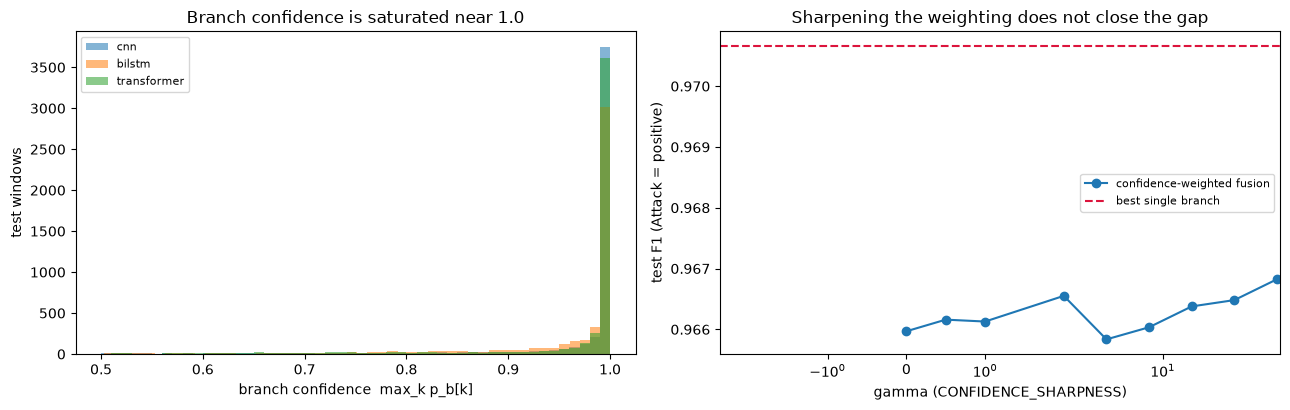

Best single branch F1        : 0.9707
Fusion F1 at gamma = 1.0     : 0.9661
Fusion F1 at best gamma      : 0.9668 (gamma = 64.0)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for name, probabilities in branch_probabilities.items():
    axes[0].hist(probabilities.max(axis=1), bins=50, alpha=0.55, label=name)
axes[0].set_xlabel("branch confidence  max_k p_b[k]")
axes[0].set_ylabel("test windows")
axes[0].set_title("Branch confidence is saturated near 1.0")
axes[0].legend(fontsize=8)

# Does sharpening the weighting recover the best branch's performance?
gammas = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0]
gamma_f1 = []
for gamma in gammas:
    swept = confidence_weighted_fusion(
        [branch_probabilities[n] for n in branch_names], branch_names, gamma=gamma
    )
    gamma_f1.append(compute_metrics(y_test, swept.predictions, f"gamma={gamma}").f1)

best_branch_f1 = max(r.f1 for r in branch_results)
axes[1].plot(gammas, gamma_f1, marker="o", label="confidence-weighted fusion")
axes[1].axhline(best_branch_f1, color="crimson", ls="--", label="best single branch")
axes[1].set_xscale("symlog"); axes[1].set_xlabel("gamma (CONFIDENCE_SHARPNESS)")
axes[1].set_ylabel("test F1 (Attack = positive)")
axes[1].set_title("Sharpening the weighting does not close the gap")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Best single branch F1        : {best_branch_f1:.4f}")
print(f"Fusion F1 at gamma = 1.0     : {gamma_f1[gammas.index(1.0)]:.4f}")
print(f"Fusion F1 at best gamma      : {max(gamma_f1):.4f} (gamma = {gammas[int(np.argmax(gamma_f1))]})")

**Reading the diagnosis.** If the weights sit near 1/3 and the gamma sweep is flat, then the
fusion formula is not the problem — *branch calibration* is. Confidence-weighted voting is a sound
rule that is being fed an input it cannot use, because every branch claims near-certainty.

This is a concrete, actionable finding rather than a dead end, and it gives Phase 3 and Phase 4
their direction:

- **T3.5 (incremental learning)** already updates `BRANCH_PRIORS` (`alpha_b`), the fusion layer's
  only adjustable parameter. Fitting `alpha_b` on the validation fold — rather than leaving all
  three at 1.0 — is the natural way to let a genuinely better branch carry more weight, and it
  needs no architectural change.
- **T4.4 (ablation)** must report the single-branch results alongside the fused ones. On this
  dataset the honest headline is that the best single branch beats the ensemble, and
  `reports/ablation_study.md` has to say so.
- A calibration step (temperature scaling on each branch's logits, fitted on the validation fold)
  is the standard fix and would make the confidences informative. It is **not** implemented here,
  because it is not in the frozen `docs/architecture_decision.md` §3.1 and inventing it mid-phase
  would be exactly the undocumented drift this project criticises. It is recorded as a Phase 3
  proposal.

## Step 10 — The comparison that matters: ensemble vs. the leakage-free baseline

`reports/t1_2_leakage_free_baseline.csv` is pipeline **C** from T1.2 — the honest, deduplicated
Random Forest. That is the only number this project compares against.

In [18]:
baseline_path = REPO_ROOT / "reports" / "t1_2_leakage_free_baseline.csv"
baseline = pd.read_csv(baseline_path).iloc[0] if baseline_path.exists() else None

comparison = results_table(branch_results + fusion_variants)
if baseline is not None:
    comparison = pd.concat(
        [pd.DataFrame([{
            "model": "T1.2 baseline: Random Forest (rows, not sequences)",
            "positive_class": baseline["positive_class"],
            "accuracy": baseline["accuracy"], "precision": baseline["precision"],
            "recall": baseline["recall"], "f1": baseline["f1"],
            "TP": baseline["TP"], "FP": baseline["FP"],
            "TN": baseline["TN"], "FN": baseline["FN"],
            "hand_verified": baseline["hand_verified"],
        }]), comparison],
        ignore_index=True,
    )

comparison.to_csv(REPO_ROOT / "reports" / "t2_6_ensemble_results.csv", index=False)
print(POSITIVE_CLASS_STATEMENT)
print()
comparison[["model", "accuracy", "precision", "recall", "f1", "FP", "FN"]]

POSITIVE CLASS = Attack (label 1); negative class = Normal (label 0). This is TRD.md §2.3's convention and is the OPPOSITE of the base paper's, which uses Normal as positive (PRD.md §2.1.3).



,model,accuracy,precision,recall,f1,FP,FN
0,"T1.2 baseline: Random Forest (rows, not sequen...",0.996444,0.997057,0.998974,0.998015,69,24
1,cnn branch alone,0.922967,0.940816,0.972802,0.956542,261,116
2,bilstm branch alone,0.927054,0.929451,0.991559,0.959501,321,36
3,transformer branch alone,0.948713,0.967832,0.973505,0.970660,138,113
4,ENSEMBLE (confidence-weighted fusion),0.939926,0.949717,0.983118,0.966129,222,72
5,FUSION baseline: simple average,0.939518,0.947665,0.984994,0.965969,232,64
6,FUSION baseline: majority vote,0.940744,0.944730,0.989918,0.966796,247,43


In [19]:
metadata = {
    "sequence_shape": list(X_train.shape),
    "sequence_length": int(SEQUENCE_LENGTH),
    "n_features": int(n_features),
    "train_windows": int(len(y_train)),
    "test_windows": int(len(y_test)),
    "val_windows": int(len(y_val)),
    "train_attack_rate": float((y_train == 1).mean()),
    "test_attack_rate": float((y_test == 1).mean()),
    "sessions": {"train": len(train_sessions), "test": len(test_sessions), "val": len(val_sessions)},
    "parameters": {name: int(model.count_params()) for name, model in models.items()},
    "epochs_run": {name: len(h.history["loss"]) for name, h in histories.items()},
    "train_seconds": {name: round(seconds, 1) for name, seconds in train_seconds.items()},
    "dominant_branch_share": (dominant.value_counts(normalize=True)).round(4).to_dict(),
    "mean_fused_confidence": float(fusion.confidence.mean()),
}
(REPO_ROOT / "reports" / "t2_6_run_metadata.json").write_text(
    json.dumps(metadata, indent=2), encoding="utf-8"
)
print(json.dumps(metadata, indent=2))

{
  "sequence_shape": [
    41284,
    10,
    62
  ],
  "sequence_length": 10,
  "n_features": 62,
  "train_windows": 41284,
  "test_windows": 4894,
  "val_windows": 4700,
  "train_attack_rate": 0.896376320124019,
  "test_attack_rate": 0.8714752758479771,
  "sessions": {
    "train": 1475,
    "test": 1315,
    "val": 1452
  },
  "parameters": {
    "cnn": 62466,
    "bilstm": 172226,
    "transformer": 71106
  },
  "epochs_run": {
    "cnn": 27,
    "bilstm": 18,
    "transformer": 20
  },
  "train_seconds": {
    "cnn": 37.0,
    "bilstm": 94.3,
    "transformer": 77.5
  },
  "dominant_branch_share": {
    "cnn": 0.6148,
    "transformer": 0.2154,
    "bilstm": 0.1698
  },
  "mean_fused_confidence": 0.9490439668019219
}


## Step 11 — Persist artifacts for Phase 3

The XAI modules (T3.1 SHAP, T3.2 LIME) and the adaptive/incremental modules (T3.4, T3.5) all need
the *trained* ensemble, not a retrained one — an explanation of a different model than the one
evaluated above would be worthless. Everything Phase 3 needs is written to `artifacts/`
(gitignored: model weights are build outputs, not source).

The background sample for SHAP is drawn from the **training** fold. Drawing it from test data
would leak the evaluation set into the explanations.

In [20]:
ARTIFACTS = REPO_ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
(ARTIFACTS / "models").mkdir(exist_ok=True)

for name, model in models.items():
    model.save(ARTIFACTS / "models" / f"{name}.keras")

rng = np.random.default_rng(RANDOM_STATE)
background_index = rng.choice(len(X_train), size=min(500, len(X_train)), replace=False)

np.savez_compressed(
    ARTIFACTS / "ensemble_artifacts.npz",
    X_test=X_test,
    y_test=y_test,
    X_background=X_train[background_index],
    fused_predictions=fusion.predictions,
    fused_confidence=fusion.confidence,
    branch_weights=fusion.branch_weights,
    **{f"probabilities_{name}": branch_probabilities[name] for name in branch_names},
)
(ARTIFACTS / "feature_names.json").write_text(
    json.dumps({"feature_names": list(selector.selected_features_),
                "branch_names": branch_names,
                "sequence_length": int(SEQUENCE_LENGTH)}, indent=2),
    encoding="utf-8",
)

print(f"Saved to {ARTIFACTS}:")
for path in sorted(ARTIFACTS.rglob("*")):
    if path.is_file():
        print(f"  {path.relative_to(ARTIFACTS)}  ({path.stat().st_size / 1024:.0f} KB)")

Saved to /Users/rohithpranov/Downloads/CN/artifacts:
  ensemble_artifacts.npz  (1707 KB)
  feature_names.json  (1 KB)
  models/bilstm.keras  (2083 KB)
  models/cnn.keras  (784 KB)
  models/transformer.keras  (969 KB)


## Verdict (T2.6 VERIFY block)

The VERIFY condition is: *"Report exists, states positive class explicitly, includes a
hand-verified metric, and makes an honest (not inflated) comparison against the T1.2 baseline."*

- **Positive class:** stated in the header, printed by every metrics block, carried as a column in
  every saved table.
- **Hand-verified:** every metric above passes `hand_verify_metrics`, which recomputes it from the
  raw TP/FP/TN/FN cells and asserts agreement with scikit-learn.
- **Honest comparison:** `reports/phase2_results.md` is written from these numbers, including the
  caveats below.

### Caveats that must travel with these numbers

1. **The ensemble and the baseline handle imbalance differently.** The baseline uses SMOTE on the
   training fold; the ensemble uses class weights, because SMOTE on flow *sequences* would
   fabricate physically impossible sessions (`train_utils` docstring). The comparison is still
   meaningful — both are leakage-free and evaluated on real, unseen traffic — but it is not a
   single-variable comparison.
2. **They are evaluated on different units.** The baseline classifies individual flow *records*;
   the ensemble classifies 10-record *windows*. A window-level F1 and a record-level F1 are not
   the same quantity.
3. **IoTID20's sessions are 100% label-pure**, because each attack scenario was captured
   separately. That makes the sequence task easier than a live deployment, where an attack begins
   mid-session. This inflates all sequence-model results here relative to reality, and Edge-IIoTset
   (T3.6) is the check on how much.
4. **Nothing here is compared to the base paper's headline numbers.** Where `final_comparison.md`
   (T4.4) does cite them, the metric-inversion caveat (`PRD.md §10`) must appear in the same
   paragraph.